# CNN Classification Model to Investigate Cell Image Types

### Importing required libraries

In [1]:
import pickle
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import seaborn as sns

### Setting up the GPU Device

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


### Setting the seed for reproducibility

In [3]:
SEED = 56  # Random seed for reproducibility

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

## Data Preparation

### Extracting labels and determining number of classes

In [5]:
# Configuration

pkl_directory = "imaging/dataset_extraction/cell_dataset/" # The PKL Directory
TARGET_H, TARGET_W =  224, 224 # Target dimensions for resizing images
USE_GRAYSCALE = True  # Whether to use grayscale images
BATCH_SIZE = 64  # Batch size for training
NUM_WORKERS = 4

In [6]:
cell_labels = []
cell_images = []
for pkl_file in Path(pkl_directory).glob("*.pkl"):
   with open(pkl_file, "rb") as f:
      entry = pickle.load(f)

   cell_labels.extend(entry["labels"])
   cell_images.extend(entry["data"])

In [7]:
y = np.asarray(cell_labels, dtype=np.int64)
num_classes = int(np.max(y)) + 1
print(f"Number of classes: {num_classes}")

Number of classes: 3


In [8]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
idx_2 = np.where(y == 2)[0]
target_n = min(len(idx_0), len(idx_1), len(idx_2))

rng = np.random.default_rng(SEED)
selected_idx_0 = rng.choice(idx_0, size=target_n, replace=False)
selected_idx_1 = rng.choice(idx_1, size=target_n, replace=False)
selected_idx_2 = rng.choice(idx_2, size=target_n, replace=False)

selected_indices = np.concatenate([selected_idx_0, selected_idx_1, selected_idx_2])
rng.shuffle(selected_indices)
X = [cell_images[i] for i in selected_indices]
y = y[selected_indices]

In [9]:
print(f"Total samples after balancing: {len(X)}")

Total samples after balancing: 19866


### Defining the Dataset class and Building the Dataset

In [10]:
class CellsDataset(Dataset):
    def __init__(self, images, labels, transform=True, grayscale=USE_GRAYSCALE):
        self.images = images
        self.labels = labels
        self.transform = transform

        base = []
        base += [T.ToPILImage()]
        base += [T.Resize((TARGET_H, TARGET_W), antialias=True)]
        
        if grayscale:
            base += [T.Grayscale(num_output_channels=1)]
        
        base += [T.ToTensor()]
        self.to_tensor = T.Compose(base)
        self.normalize = None
    
    def set_normalize(self, mean, std):
        self.normalize = T.Normalize(mean=mean, std=std)
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if image.ndim == 2:
            pass
        elif image.ndim == 3:
            pass
        else:
            raise ValueError(f"Unexpected image dimensions: {image.ndim}")
        
        x = self.to_tensor(image)
        if self.normalize is not None:
            x = self.normalize(x)
        y = int(self.labels[idx])
        return x, y

In [11]:
# Stratified Split into Train, Validation, and Test Sets (Stratification helps maintain class distribution across splits)

idx = np.arange(len(y))
train_idx, temp_idx, y_train, y_temp = train_test_split(idx, y, test_size=0.3, random_state=SEED, stratify=y)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

In [12]:
# Defining the datasets

train_dataset = CellsDataset(
    images=[X[i] for i in train_idx],
    labels=y_train,
    transform=True,
    grayscale=USE_GRAYSCALE
)

val_dataset = CellsDataset(
    images=[X[i] for i in val_idx],
    labels=y_val,
    transform=False,
    grayscale=USE_GRAYSCALE
)

test_dataset = CellsDataset(
    images=[X[i] for i in test_idx],
    labels=y_test,
    transform=False,
    grayscale=USE_GRAYSCALE
)

In [13]:
# Calculating mean and std for normalization across the training dataset   

temp_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
channels = 1 if USE_GRAYSCALE else 3
sum_, sum_sq, num_pixels = torch.zeros(channels), torch.zeros(channels), 0

for batch_imgs, _ in temp_loader:
    B, C, H, W = batch_imgs.shape
    n = B * H * W
    sum_ += batch_imgs.sum(dim=(0, 2, 3))
    sum_sq += (batch_imgs ** 2).sum(dim=(0, 2, 3))
    num_pixels += n

mean = (sum_ / num_pixels).tolist()
std = torch.sqrt((sum_sq / num_pixels) - ((sum_ / num_pixels) ** 2)).tolist()

# Setting normalization for datasets according to the calculated mean and std of the training set
train_dataset.set_normalize(mean, std)
val_dataset.set_normalize(mean, std)
test_dataset.set_normalize(mean, std)

In [14]:
# Using a WeightedRandomSampler to handle class imbalance in the training dataset
class_counts = Counter(y_train)
class_weights = torch.tensor([1.0 / class_counts[i] for i in range(num_classes)], dtype=torch.float)
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [15]:
# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [16]:
print("Train Counts:", Counter(y_train))
print("Validation Counts:", Counter(y_val))
print("Test Counts:", Counter(y_test))
print("Normalize Mean and Std:", mean, std)

Train Counts: Counter({np.int64(2): 4636, np.int64(0): 4635, np.int64(1): 4635})
Validation Counts: Counter({np.int64(0): 994, np.int64(2): 993, np.int64(1): 993})
Test Counts: Counter({np.int64(1): 994, np.int64(2): 993, np.int64(0): 993})
Normalize Mean and Std: [0.7400842308998108] [0.08103924244642258]


## Model Definition

In [17]:
CIN = 1 if USE_GRAYSCALE else 3

## Model Definition
class CellClassifierCNN(nn.Module):
    def __init__(self, num_classes, cin=CIN):
        super(CellClassifierCNN, self).__init__()
        self.conv1 = nn.Conv2d(cin, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * (TARGET_H // 8) * (TARGET_W // 8), 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * (TARGET_H // 8) * (TARGET_W // 8))
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [18]:
def print_metrics(y_true, y_pred, label=""):
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0, 1, 2])
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    print(f"\n{label} metrics:")
    for cls in [0, 1, 2]:
        tp = ((y_true == cls) & (y_pred == cls)).sum()
        fp = ((y_true != cls) & (y_pred == cls)).sum()
        fn = ((y_true == cls) & (y_pred != cls)).sum()
        print(f"Class {cls}:")
        print(f"  TP={tp}, FP={fp}, FN={fn}")
        print(f"  Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision[cls]:.4f}")
        print(f"  Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall[cls]:.4f}")
        print(f"  F1        = 2 * (P*R)/(P+R) = 2*({precision[cls]:.4f}*{recall[cls]:.4f})/({precision[cls]:.4f}+{recall[cls]:.4f}) = {f1[cls]:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall:    {recall_macro:.4f}")
    print(f"Macro F1:        {f1_macro:.4f}")


In [19]:
def train_loop(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct = 0.0, 0
    train_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Train]", leave=False)
    y_true_train, y_pred_train = [], []
    for inputs, labels in train_iter:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Train Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_train, y_pred_train))
    return epoch_loss

In [20]:
def validation_loop(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss, correct = 0.0, 0
    val_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Val]", leave=False)
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for inputs, labels in val_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Validation Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_val, y_pred_val))
    return epoch_loss

In [21]:
def test_loop(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct = 0.0, 0
    test_iter = tqdm(dataloader, desc=f"[Test]", leave=False)
    y_true_test, y_pred_test = [], []
    with torch.no_grad():
        for inputs, labels in test_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Test Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_test, y_pred_test))
    print_metrics(np.array(y_true_test), np.array(y_pred_test), label="Test")
    
    sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt="d")
    plt.title('Confusion Matrix', fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top') 
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    
    plt.show()
    return epoch_loss

In [22]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0.0, mode = 'max', restore_best_weights = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_path = "CNN_best_model.pth"
    
    def is_improved(self, current_score):
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return current_score > self.best_score + self.min_delta
        else: # in the case of 'min'
            return current_score < self.best_score - self.min_delta
        
    def step(self, current_score, model):
        if self.is_improved(current_score):
            self.best_score = current_score
            self.counter = 0
            torch.save(model.state_dict(), self.best_path)
        else:
            self.counter += 1
            return self.counter >= self.patience
        
    def restore_weights(self, model, map_location=None):
        if self.restore_best_weights and self.best_score is not None:
            model.load_state_dict(torch.load(self.best_path, map_location=map_location))
        

## Using the Model

In [23]:
# Defining model, criterion, and optimizer
model = CellClassifierCNN(num_classes=num_classes, cin=CIN).to(device)
counts = torch.tensor([Counter(y_train)[i] for i in range(num_classes)], dtype=torch.float)
weights = (1.0 / counts).clamp(max = (1.0 / counts.min()))
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [27]:
# TRAINING

EPOCHS = 50
best_val = -float('inf')
best_epoch = 0
stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max', restore_best_weights=True)

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_loop(model, train_loader, criterion, optimizer, device, epoch)
    val_loss = validation_loop(model, val_loader, criterion, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss[0]:.4f}, Train Acc: {train_loss[1]:.4f} | Val Loss: {val_loss[0]:.4f}, Val Acc: {val_loss[1]:.4f}")

    if val_loss[1] > best_val:
        best_val = val_loss[1]
        best_epoch = epoch
        print(f"New best model found at epoch {epoch}")
    
    if stopper.step(val_loss[1], model):
        print(f"Early stopping at epoch {epoch}: Best epoch was {best_epoch} with validation accuracy {best_val:.4f}.")
        stopper.restore_weights(model, map_location=device)
        break
    
    
print(f"Training complete. Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Epoch 1/50


Train Loss: 0.9214, Accuracy: 0.5820
              precision    recall  f1-score   support

           0       0.59      0.71      0.64      4759
           1       0.49      0.55      0.52      4523
           2       0.71      0.49      0.58      4624

    accuracy                           0.58     13906
   macro avg       0.60      0.58      0.58     13906
weighted avg       0.60      0.58      0.58     13906



Validation Loss: 0.6901, Accuracy: 0.6846
              precision    recall  f1-score   support

           0       0.71      0.91      0.80       994
           1       0.61      0.61      0.61       993
           2       0.73      0.54      0.62       993

    accuracy                           0.68      2980
   macro avg       0.69      0.68      0.68      2980
weighted avg       0.69      0.68      0.68      2980

Epoch 01 | Train Loss: 0.9214, Train Acc: 0.5820 | Val Loss: 0.6901, Val Acc: 0.6846
New best model found at epoch 1
Epoch 2/50


Train Loss: 0.6865, Accuracy: 0.6983
              precision    recall  f1-score   support

           0       0.78      0.85      0.81      4637
           1       0.60      0.70      0.64      4576
           2       0.74      0.55      0.63      4693

    accuracy                           0.70     13906
   macro avg       0.70      0.70      0.70     13906
weighted avg       0.71      0.70      0.70     13906



Validation Loss: 0.5413, Accuracy: 0.7668
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       994
           1       0.65      0.79      0.72       993
           2       0.83      0.60      0.69       993

    accuracy                           0.77      2980
   macro avg       0.78      0.77      0.76      2980
weighted avg       0.78      0.77      0.76      2980

Epoch 02 | Train Loss: 0.6865, Train Acc: 0.6983 | Val Loss: 0.5413, Val Acc: 0.7668
New best model found at epoch 2
Epoch 3/50


...

Validation Loss: 0.2670, Accuracy: 0.8772
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       994
           1       0.86      0.75      0.81       993
           2       0.81      0.89      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980

Epoch 13 | Train Loss: 0.2520, Train Acc: 0.8866 | Val Loss: 0.2670, Val Acc: 0.8772
Epoch 14/50


Train Loss: 0.2393, Accuracy: 0.8860
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4676
           1       0.83      0.83      0.83      4577
           2       0.86      0.84      0.85      4653

    accuracy                           0.89     13906
   macro avg       0.88      0.89      0.89     13906
weighted avg       0.89      0.89      0.89     13906



Validation Loss: 0.2691, Accuracy: 0.8789
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       994
           1       0.82      0.82      0.82       993
           2       0.87      0.82      0.84       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980

Epoch 14 | Train Loss: 0.2393, Train Acc: 0.8860 | Val Loss: 0.2691, Val Acc: 0.8789
Epoch 15/50


Train Loss: 0.2406, Accuracy: 0.8877
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4594
           1       0.83      0.84      0.84      4680
           2       0.86      0.84      0.85      4632

    accuracy                           0.89     13906
   macro avg       0.89      0.89      0.89     13906
weighted avg       0.89      0.89      0.89     13906



Validation Loss: 0.2806, Accuracy: 0.8732
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       994
           1       0.79      0.85      0.82       993
           2       0.87      0.81      0.83       993

    accuracy                           0.87      2980
   macro avg       0.87      0.87      0.87      2980
weighted avg       0.87      0.87      0.87      2980

Epoch 15 | Train Loss: 0.2406, Train Acc: 0.8877 | Val Loss: 0.2806, Val Acc: 0.8732
Early stopping at epoch 15: Best epoch was 10 with validation accuracy 0.8819.
Training complete. Best validation accuracy: 0.8819 at epoch 10


Test Loss: 0.2652, Accuracy: 0.8842
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       993
           1       0.84      0.82      0.83       994
           2       0.86      0.85      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980


Test metrics:
Class 0:
  TP=980, FP=47, FN=13
  Precision = TP / (TP + FP) = 980 / (980 + 47) = 0.9542
  Recall    = TP / (TP + FN) = 980 / (980 + 13) = 0.9869
  F1        = 2 * (P*R)/(P+R) = 2*(0.9542*0.9869)/(0.9542+0.9869) = 0.9703
Class 1:
  TP=813, FP=157, FN=181
  Precision = TP / (TP + FP) = 813 / (813 + 157) = 0.8381
  Recall    = TP / (TP + FN) = 813 / (813 + 181) = 0.8179
  F1        = 2 * (P*R)/(P+R) = 2*(0.8381*0.8179)/(0.8381+0.8179) = 0.8279
Class 2:
  TP=842, FP=141, FN=151
  Precision = TP / (TP + FP) = 842 / (842 + 141) = 0.8566
  Recall    = TP / (TP + FN) =

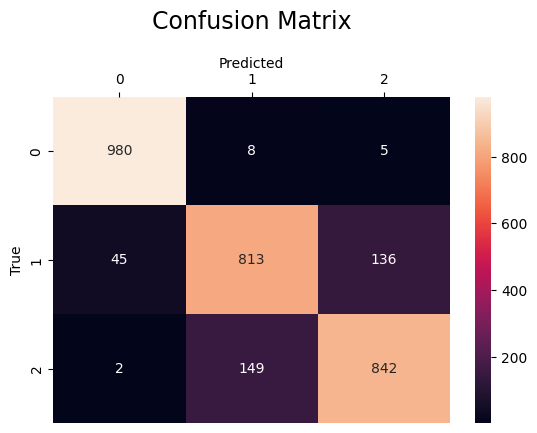

Test Loss: 0.2652, Test Accuracy: 0.8842


In [24]:
# Load the best model for testing

model.load_state_dict(torch.load("CNN_best_model.pth"))
test_loss = test_loop(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss[0]:.4f}, Test Accuracy: {test_loss[1]:.4f}")

Test Loss: 0.2239, Accuracy: 0.8998
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4758
           1       0.85      0.84      0.85      4524
           2       0.87      0.86      0.87      4624

    accuracy                           0.90     13906
   macro avg       0.90      0.90      0.90     13906
weighted avg       0.90      0.90      0.90     13906


Test metrics:
Class 0:
  TP=4739, FP=151, FN=19
  Precision = TP / (TP + FP) = 4739 / (4739 + 151) = 0.9691
  Recall    = TP / (TP + FN) = 4739 / (4739 + 19) = 0.9960
  F1        = 2 * (P*R)/(P+R) = 2*(0.9691*0.9960)/(0.9691+0.9960) = 0.9824
Class 1:
  TP=3802, FP=664, FN=722
  Precision = TP / (TP + FP) = 3802 / (3802 + 664) = 0.8513
  Recall    = TP / (TP + FN) = 3802 / (3802 + 722) = 0.8404
  F1        = 2 * (P*R)/(P+R) = 2*(0.8513*0.8404)/(0.8513+0.8404) = 0.8458
Class 2:
  TP=3972, FP=578, FN=652
  Precision = TP / (TP + FP) = 3972 / (3972 + 578) = 0.8730
  Recall    = T

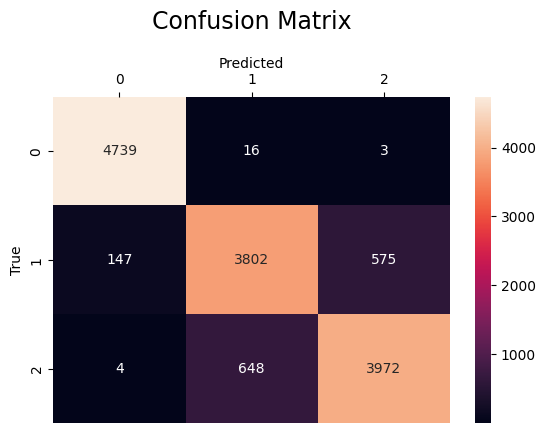

Train Loss: 0.2239, Train Accuracy: 0.8998


In [25]:
# Load the best model for testing

model.load_state_dict(torch.load("CNN_best_model.pth"))
train_loss = test_loop(model, train_loader, criterion, device)
print(f"Train Loss: {train_loss[0]:.4f}, Train Accuracy: {train_loss[1]:.4f}")

Test Loss: 0.2780, Accuracy: 0.8819
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       994
           1       0.83      0.82      0.82       993
           2       0.86      0.85      0.85       993

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980


Test metrics:
Class 0:
  TP=978, FP=47, FN=16
  Precision = TP / (TP + FP) = 978 / (978 + 47) = 0.9541
  Recall    = TP / (TP + FN) = 978 / (978 + 16) = 0.9839
  F1        = 2 * (P*R)/(P+R) = 2*(0.9541*0.9839)/(0.9541+0.9839) = 0.9688
Class 1:
  TP=810, FP=163, FN=183
  Precision = TP / (TP + FP) = 810 / (810 + 163) = 0.8325
  Recall    = TP / (TP + FN) = 810 / (810 + 183) = 0.8157
  F1        = 2 * (P*R)/(P+R) = 2*(0.8325*0.8157)/(0.8325+0.8157) = 0.8240
Class 2:
  TP=840, FP=142, FN=153
  Precision = TP / (TP + FP) = 840 / (840 + 142) = 0.8554
  Recall    = TP / (TP + FN) =

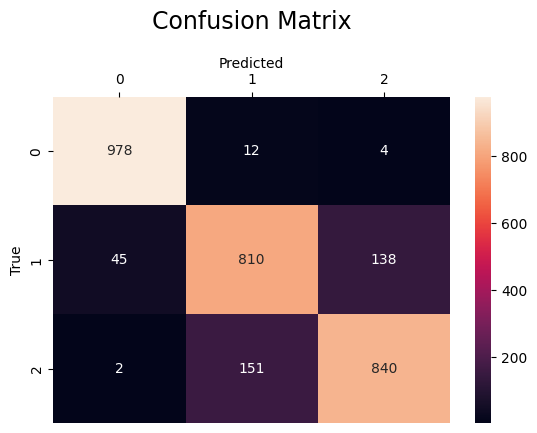

Validation Loss: 0.2780, Validation Accuracy: 0.8819


In [26]:
# Load the best model for testing

model.load_state_dict(torch.load("CNN_best_model.pth"))
val_loss = test_loop(model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss[0]:.4f}, Validation Accuracy: {val_loss[1]:.4f}")